In [21]:
print("hello world")

hello world


## Logistic Regression 

                 Machine Learning Workflow
 ┌───────────────────────────────────────────────┐
 │ 1. Import Required Libraries                  │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 2. Read or Load the Dataset                   │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 3. Understand the Dataset                     │
 │    • Shape                                    │
 │    • Columns                                  │
 │    • Data Types                               │
 │    • Missing Values                           │
 │    • Statistics                               │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 4. Visualize the Dataset                      │
 │    • Scatter Plot                             │
 │    • Histogram                                │
 │    • Box Plot                                 │
 │    • Correlation Heatmap                      │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 5. Data Preprocessing                         │
 │    • Remove Missing Values                    │
 │    • Remove Duplicates                        │
 │    • Handle Outliers                          │
 │    • Feature Scaling (if needed)              │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 6. Select Input and Output Variables          │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 7. Split into Training & Testing Data         │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 8. Create the Linear Regression Model         │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │ 9. Train (Fit) the Model                      │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │10. Make Predictions                           │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │11. Evaluate the Model                         │
 │   • MSE                                      │
 │   • RMSE                                     │
 │   • MAE                                      │
 │   • R² Score                                 │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │12. Visualize the Regression Line              │
 └───────────────────────────────────────────────┘
                    │
                    ▼
 ┌───────────────────────────────────────────────┐
 │13. Predict New Data                           │
 └───────────────────────────────────────────────┘

In [22]:
# ==========================================================
# Linear Regression & Logistic Regression - Complete Example
# ==========================================================
# This script demonstrates:
# 1. Creating a synthetic dataset
# 2. Viewing the input data
# 3. Splitting into training/testing sets
# 4. Training Linear Regression
# 5. Training Logistic Regression
# 6. Evaluating both models
# 7. Visualizing train/test data and model predictions
# 8. Predicting results for new students
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)


In [23]:

# -----------------------------
# Create Synthetic Dataset
# -----------------------------
np.random.seed(42)

study_hours = np.random.uniform(0, 10, 100).reshape(-1,1)
noise = np.random.normal(0,5,100)
true_slope = 8
true_intercept = 30
exam_scores = true_slope*study_hours.flatten()+true_intercept+noise
pass_fail = (exam_scores>=50).astype(int)

# -----------------------------
# Display Input Dataset
# -----------------------------
dataset = pd.DataFrame({
    "Study Hours":study_hours.flatten(),
    "Exam Score":exam_scores,
    "Pass/Fail":pass_fail
})

print("\nINPUT DATASET")
print("="*70)
print(dataset)



INPUT DATASET
    Study Hours  Exam Score  Pass/Fail
0      3.745401   60.398445          1
1      9.507143  104.562108          1
2      7.319939   89.018319          1
3      5.986585   67.954834          1
4      1.560186   41.383132          0
..          ...         ...        ...
95     4.937956   65.424596          1
96     5.227328   71.433118          1
97     4.275410   65.909041          1
98     0.254191   33.416984          0
99     1.078914   42.767230          0

[100 rows x 3 columns]


## UNDERSTANDING THE DATASET

In [35]:
# =====================================================
# PART 2A: UNDERSTANDING THE DATASET
# =====================================================

print("\n" + "="*70)
print("UNDERSTANDING THE DATASET")
print("="*70)



UNDERSTANDING THE DATASET


In [36]:

# Display the first 5 rows
print("\nFirst 5 Records")
print(dataset.head())



First 5 Records
   Study Hours  Exam Score  Pass/Fail
0     3.745401   60.398445          1
1     9.507143  104.562108          1
2     7.319939   89.018319          1
3     5.986585   67.954834          1
4     1.560186   41.383132          0


In [37]:
# Display the last 5 rows
print("\nLast 5 Records")
print(dataset.tail())



Last 5 Records
    Study Hours  Exam Score  Pass/Fail
95     4.937956   65.424596          1
96     5.227328   71.433118          1
97     4.275410   65.909041          1
98     0.254191   33.416984          0
99     1.078914   42.767230          0


In [38]:
# Shape of the dataset
print("\nDataset Shape")
print(dataset.shape)



Dataset Shape
(100, 3)


In [39]:
# Column Names
print("\nColumn Names")
print(dataset.columns)



Column Names
Index(['Study Hours', 'Exam Score', 'Pass/Fail'], dtype='str')


In [40]:
# Information about the dataset
print("\nDataset Information")
dataset.info()



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  100 non-null    float64
 1   Exam Score   100 non-null    float64
 2   Pass/Fail    100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [41]:

# Statistical Summary
print("\nStatistical Summary")
print(dataset.describe())



Statistical Summary
       Study Hours  Exam Score   Pass/Fail
count   100.000000  100.000000  100.000000
mean      4.701807   67.609058    0.720000
std       2.974894   23.551725    0.451261
min       0.055221   29.021062    0.000000
25%       1.932008   47.530132    0.000000
50%       4.641425   65.010391    1.000000
75%       7.302031   88.480708    1.000000
max       9.868869  112.860069    1.000000


In [42]:


# Missing Values
print("\nMissing Values")
print(dataset.isnull().sum())



Missing Values
Study Hours    0
Exam Score     0
Pass/Fail      0
dtype: int64


In [43]:




# Duplicate Records
print("\nDuplicate Records")
print(dataset.duplicated().sum())


Duplicate Records
0


In [25]:
# -----------------------------
# Train/Test Split
# -----------------------------
X_train_lr,X_test_lr,y_train_lr,y_test_lr = train_test_split(
    study_hours,exam_scores,test_size=0.30,random_state=42
)

X_train_log,X_test_log,y_train_log,y_test_log = train_test_split(
    study_hours,pass_fail,test_size=0.30,
    random_state=42,stratify=pass_fail
)


In [26]:
print("\nLINEAR REGRESSION - TRAIN DATA")
print(pd.DataFrame({
    "Hours":X_train_lr.flatten(),
    "Score":y_train_lr
}))



LINEAR REGRESSION - TRAIN DATA
       Hours       Score
0   9.699099  109.236544
1   5.200680   64.596186
2   3.251833   59.950089
3   5.924146   76.586737
4   5.612772   71.133495
..       ...         ...
65  3.886773   57.177917
66  1.987157   39.294971
67  1.818250   45.031385
68  7.607850   89.635863
69  7.751328   89.179137

[70 rows x 2 columns]


In [27]:
print("\nLINEAR REGRESSION - TEST DATA")
print(pd.DataFrame({
    "Hours":X_test_lr.flatten(),
    "Score":y_test_lr
}))



LINEAR REGRESSION - TEST DATA
       Hours       Score
0   0.635584   38.367436
1   8.948274   99.068810
2   7.722448   85.594828
3   6.625223   78.454845
4   2.587800   54.657558
5   4.401525   66.719936
6   2.921446   53.397139
7   8.631034  108.377147
8   0.205845   36.223770
9   3.745401   60.398445
10  4.319450   62.595061
11  6.075449   88.034518
12  8.154614   96.721838
13  9.488855  105.538613
14  1.195942   43.677840
15  1.560186   41.383132
16  7.712703   88.301504
17  0.740447   37.084841
18  8.324426   93.946610
19  1.705241   44.514819
20  9.218742  104.092754
21  8.872127  105.793900
22  1.996738   44.260330
23  0.343885   38.465196
24  9.868869  112.860069
25  1.834045   49.515586
26  1.220382   39.589500
27  5.227328   71.433118
28  7.080726   84.137021
29  0.055221   33.051477


In [28]:

print("\nLOGISTIC REGRESSION - TRAIN DATA")
print(pd.DataFrame({
    "Hours":X_train_log.flatten(),
    "Pass/Fail":y_train_log
}))



LOGISTIC REGRESSION - TRAIN DATA
       Hours  Pass/Fail
0   9.507143          1
1   9.093204          1
2   8.083973          1
3   9.699099          1
4   7.851760          1
..       ...        ...
65  1.560186          0
66  5.924146          1
67  0.976721          1
68  3.117111          1
69  0.740447          0

[70 rows x 2 columns]


In [29]:



print("\nLOGISTIC REGRESSION - TEST DATA")
print(pd.DataFrame({
    "Hours":X_test_log.flatten(),
    "Pass/Fail":y_test_log
}))



LOGISTIC REGRESSION - TEST DATA
       Hours  Pass/Fail
0   7.751328          1
1   1.078914          0
2   7.132448          1
3   2.912291          0
4   9.488855          1
5   8.154614          1
6   7.319939          1
7   7.712703          1
8   8.631034          1
9   8.948274          1
10  3.253303          1
11  7.607850          1
12  0.464504          0
13  6.375575          1
14  7.722448          1
15  8.021970          1
16  1.834045          0
17  0.343885          0
18  3.308980          1
19  1.987157          0
20  5.142344          1
21  7.080726          1
22  2.713490          1
23  3.109823          1
24  1.409242          0
25  0.745506          0
26  7.296062          1
27  2.809345          1
28  3.663618          1
29  8.324426          1


## VISUALIZING THE DATASET

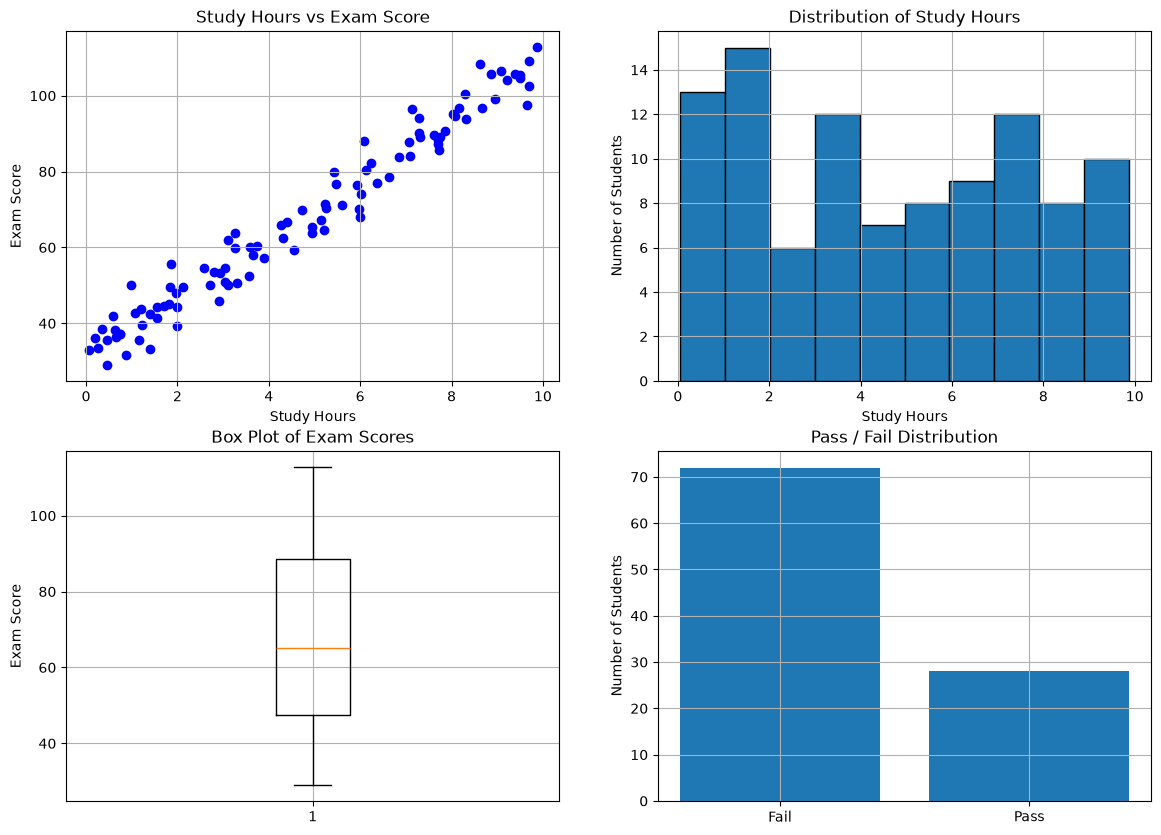

In [30]:
# =====================================================
# PART 2B: VISUALIZING THE INPUT DATASET
# =====================================================

fig, axs = plt.subplots(2, 2, figsize=(14,10))
# Scatter Plot
axs[0,0].scatter(dataset["Study Hours"],
                 dataset["Exam Score"],
                 color='blue')

axs[0,0].set_title("Study Hours vs Exam Score")
axs[0,0].set_xlabel("Study Hours")
axs[0,0].set_ylabel("Exam Score")
axs[0,0].grid(True)

# Histogram of Exam Scores
# Histogram
axs[0,1].hist(dataset["Study Hours"],
              bins=10,
              edgecolor="black")

axs[0,1].set_title("Distribution of Study Hours")
axs[0,1].set_xlabel("Study Hours")
axs[0,1].set_ylabel("Number of Students")
axs[0,1].grid(True)

# Boxplot of Exam Scores
# Box Plot
axs[1,0].boxplot(dataset["Exam Score"])

axs[1,0].set_title("Box Plot of Exam Scores")
axs[1,0].set_ylabel("Exam Score")
axs[1,0].grid(True)

# Pass / Fail Distribution

# Bar Chart
pass_count = dataset["Pass/Fail"].value_counts()

axs[1,1].bar(["Fail","Pass"], pass_count)

axs[1,1].set_title("Pass / Fail Distribution")
axs[1,1].set_ylabel("Number of Students")
axs[1,1].grid(True)

In [31]:

# -----------------------------
# Linear Regression
# -----------------------------
linear_model = LinearRegression()
linear_model.fit(X_train_lr,y_train_lr)
y_pred_lr = linear_model.predict(X_test_lr)

print("\nLINEAR REGRESSION RESULTS")
print("="*70)
print(f"Equation : Score = {linear_model.coef_[0]:.2f} x Hours + {linear_model.intercept_:.2f}")
print(f"MSE      : {mean_squared_error(y_test_lr,y_pred_lr):.2f}")
print(f"R2 Score : {r2_score(y_test_lr,y_pred_lr):.4f}")



LINEAR REGRESSION RESULTS
Equation : Score = 7.77 x Hours + 30.59
MSE      : 15.77
R2 Score : 0.9771


In [32]:
# -----------------------------
# Logistic Regression
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train_log)

y_pred_log = log_model.predict(X_test_scaled)

print("\nLOGISTIC REGRESSION RESULTS")
print("="*70)
print(f"Accuracy : {accuracy_score(y_test_log,y_pred_log):.2%}")
print("\nConfusion Matrix")
print(confusion_matrix(y_test_log,y_pred_log))
print("\nClassification Report")
print(classification_report(y_test_log,y_pred_log))



LOGISTIC REGRESSION RESULTS
Accuracy : 96.67%

Confusion Matrix
[[ 7  1]
 [ 0 22]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.96      1.00      0.98        22

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



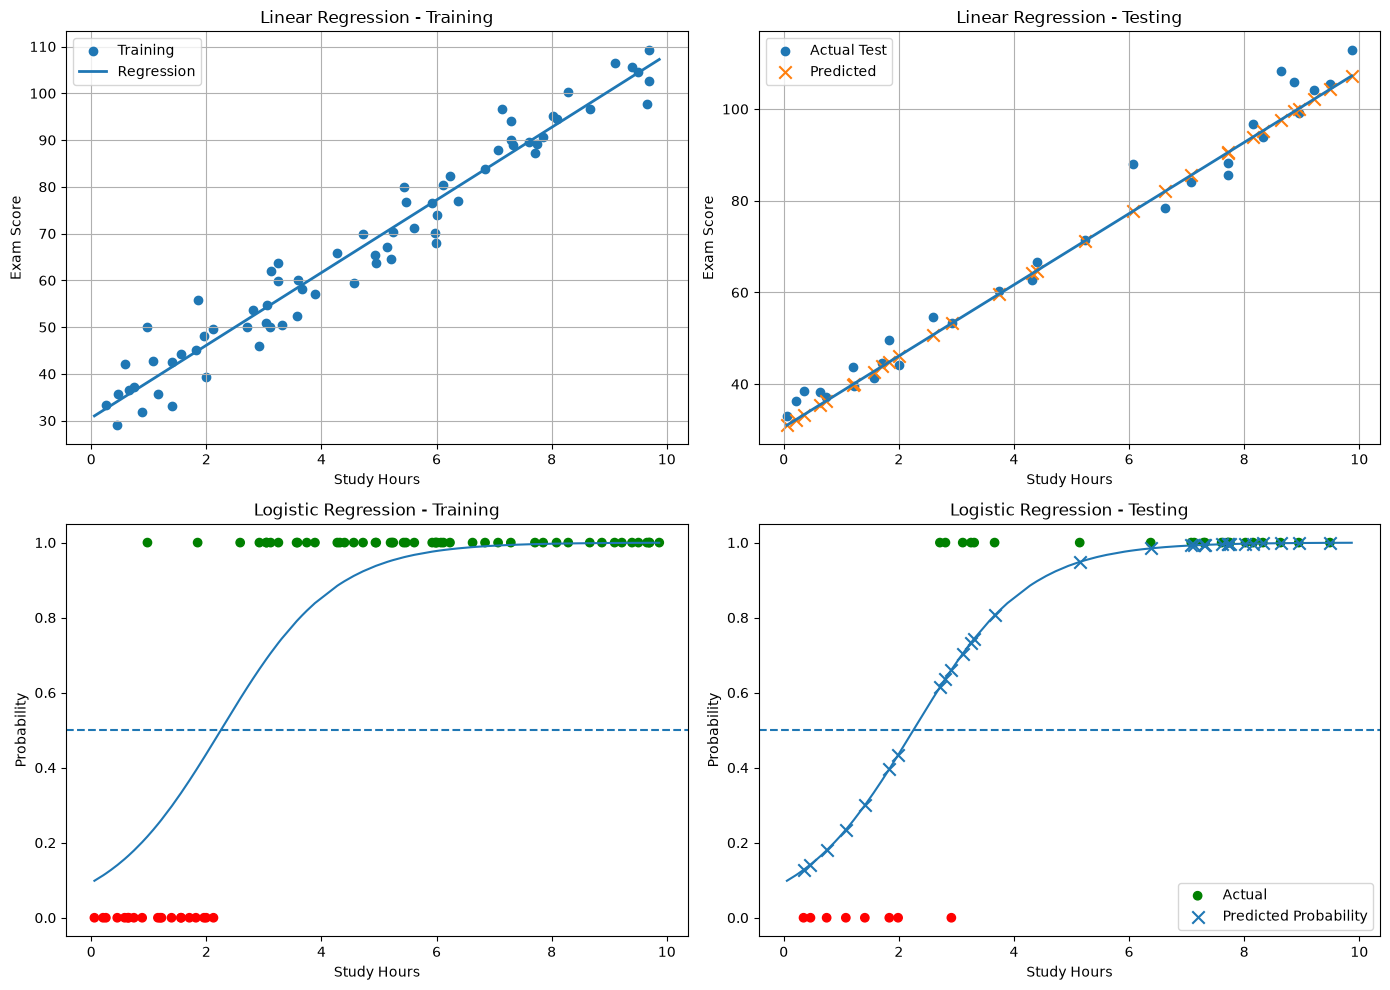

In [33]:
# -----------------------------
# Visualization
# -----------------------------
fig,axs=plt.subplots(2,2,figsize=(14,10))

# Linear Train
axs[0,0].scatter(X_train_lr,y_train_lr,label="Training")
xs=np.sort(study_hours,axis=0)
axs[0,0].plot(xs,linear_model.predict(xs),linewidth=2,label="Regression")
axs[0,0].set_title("Linear Regression - Training")
axs[0,0].set_xlabel("Study Hours")
axs[0,0].set_ylabel("Exam Score")
axs[0,0].legend()
axs[0,0].grid(True)

# Linear Test
axs[0,1].scatter(X_test_lr,y_test_lr,label="Actual Test")
axs[0,1].scatter(X_test_lr,y_pred_lr,marker="x",s=80,label="Predicted")
axs[0,1].plot(xs,linear_model.predict(xs),linewidth=2)
axs[0,1].set_title("Linear Regression - Testing")
axs[0,1].set_xlabel("Study Hours")
axs[0,1].set_ylabel("Exam Score")
axs[0,1].legend()
axs[0,1].grid(True)

# Logistic Train
colors=["red" if i==0 else "green" for i in y_train_log]
axs[1,0].scatter(X_train_log,y_train_log,c=colors)
prob=log_model.predict_proba(scaler.transform(xs))[:,1]
axs[1,0].plot(xs,prob)
axs[1,0].axhline(.5,ls="--")
axs[1,0].set_title("Logistic Regression - Training")
axs[1,0].set_xlabel("Study Hours")
axs[1,0].set_ylabel("Probability")

# Logistic Test
colors=["red" if i==0 else "green" for i in y_test_log]
axs[1,1].scatter(X_test_log,y_test_log,c=colors,label="Actual")
prob_test=log_model.predict_proba(X_test_scaled)[:,1]
axs[1,1].scatter(X_test_log,prob_test,marker="x",s=80,label="Predicted Probability")
axs[1,1].plot(xs,prob)
axs[1,1].axhline(.5,ls="--")
axs[1,1].set_title("Logistic Regression - Testing")
axs[1,1].set_xlabel("Study Hours")
axs[1,1].set_ylabel("Probability")
axs[1,1].legend()

plt.tight_layout()
plt.show()


In [34]:

# -----------------------------
# Predict New Students
# -----------------------------
new=np.array([[2.5],[5],[7.5],[9]])
scores=linear_model.predict(new)
scaled=scaler.transform(new)
classes=log_model.predict(scaled)
probs=log_model.predict_proba(scaled)[:,1]

print("\nNEW STUDENT PREDICTIONS")
print("="*70)
for h,s,c,p in zip(new.flatten(),scores,classes,probs):
    print(f"Hours={h:4.1f}  Score={s:6.2f}  Pass={bool(c)}  Probability={p:.2%}")



NEW STUDENT PREDICTIONS
Hours= 2.5  Score= 50.01  Pass=True  Probability=56.23%
Hours= 5.0  Score= 69.42  Pass=True  Probability=94.11%
Hours= 7.5  Score= 88.84  Pass=True  Probability=99.50%
Hours= 9.0  Score=100.49  Pass=True  Probability=99.89%
